In [2]:
import nk_landscape
import gaussian_markov_random_field
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
import random
import sequence_evolution
import graph_ruggedness_de
import graph_utils
import pandas as pd
from matplotlib.ticker import ScalarFormatter
import scipy.stats as stats
import statsmodels.stats.multicomp as mc
from scipy.stats import spearmanr
from timestep_opt import fit_t_bayesian_laplace
import statsmodels.stats.multicomp as mc
import matplotlib as mpl
from collections import defaultdict
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import graph_fourier_transform

### Figure 2.
The purpose of Figure 2 is to present an overview of the simulation systems and the performance of the GMRF in quantifying ruggedness, when ruggedness is a controlable parameter, between fitness landscpaes. Figure 2 uses both nk landscapes from `nk_landscape` and elementary landscapes from `graph_ruggedness_de`.

The below cell uses `sequence_evolution.sample_sequences` to simulate an evolutionary process of random phylogenetic trees, using realistic evolutionary parameters. The fitness over these sequences are computed using the `graph_ruggedness_de.compute_elementary_landscape`, which uses the `n`th Laplacian eigenvector as the signal over the graph. 

In [52]:
#Laplacian eigenvector indices
n0 = 3
n1 = 50

sample_size = 1
for _ in tqdm(enumerate(range(sample_size))):
    try:

        num_nodes = 200
        mean_branch_length = np.random.uniform(0.01, 0.5)
        std_dev_branch_length = np.random.uniform(0.001, 0.1)
        alpha = np.random.uniform(0.1, 0.5)
        model = random.choice(('WAG', 'LG'))
        rate_categoies = 4
        sequence_length = int(np.random.uniform(100, 600))

        sample_info = {
            'num_nodes' : num_nodes,
            'mean_branch_length' : mean_branch_length,
            'std_dev_branch_length' : std_dev_branch_length,
            'alpha' : alpha,
            'model' : model,
            'sequence_length' : sequence_length
        }

        seq_dict = sequence_evolution.sequence_evolution(num_nodes=num_nodes,
                                                        mean_branch_length=mean_branch_length,
                                                        std_dev_branch_length=std_dev_branch_length,
                                                        alpha=alpha,
                                                        model=model,
                                                        rate_categories=rate_categoies,
                                                        sequence_length=sequence_length
                                                        )
        seq_ls = list(seq_dict.values())
        values = [0]*len(seq_ls)
        G = graph_ruggedness_de.build_ohe_graph(seq_ls=seq_ls,
                                            values=values)
    
    except:
        continue

#Define the signals over G0 and G1 as the n0th and n1st Laplacian eignevectors.
G0 = graph_ruggedness_de.compute_elementary_landscape(G=G, n=n0)
G1 = graph_ruggedness_de.compute_elementary_landscape(G=G, n=n1)

0it [00:00, ?it/s]

Computing all vs. all OHE distance matrix.


1it [00:02,  2.30s/it]

Done.
Finding K-nearest neighbors.
Done.
Added 2800 KNN edges.


The below cell computes the maximum a posteriori t value, `t_map`, as well as the Guassian approximation of the posterior using the Laplace approximation from `timestep_opt.fit_t_bayesian_laplace`.

In [53]:
t_map, ci_lower, ci_upper, logpost_map, var_approx = fit_t_bayesian_laplace(G=G0)

/Users/matthewspence/Documents/Documents/graph-ruggedness-de/src/gaussian_markov_random_field.py:126: RuntimeWarning: divide by zero encountered in divide
  inv_h_i_scaled = 1 / h_i_scaled
/Users/matthewspence/Documents/Documents/graph-ruggedness-de/src/gaussian_markov_random_field.py:126: RuntimeWarning: overflow encountered in divide
  inv_h_i_scaled = 1 / h_i_scaled
/Users/matthewspence/Documents/Documents/graph-ruggedness-de/src/gaussian_markov_random_field.py:132: RuntimeWarning: divide by zero encountered in log
  log_det = np.sum(np.log(h_i_scaled))
/Users/matthewspence/Documents/Documents/graph-ruggedness-de/src/gaussian_markov_random_field.py:135: RuntimeWarning: invalid value encountered in scalar subtract
  log_likelihood = -0.5 * quadratic_form - 0.5 * log_det - (n / 2) * np.log(2 * np.pi)


/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_25791/882662344.py:10: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(sm, label='Fitness')


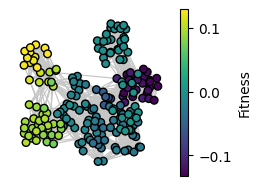

/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_25791/882662344.py:20: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(sm, label='Fitness')


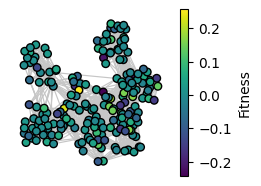

In [62]:
pos = nx.spring_layout(G, k=0.5)
signal0 = np.array([node[1]['value'] for node in G0.nodes(data=True)])
signal1 = np.array([node[1]['value'] for node in G1.nodes(data=True)])

fig, ax = plt.subplots(figsize=(2.5, 1.75), constrained_layout=True)

norm0, cmap0 = graph_utils.visualize_signal_over_graph(G=G, pos=pos, nodesize=30, signal=signal0, ax=ax)
sm = plt.cm.ScalarMappable(cmap=cmap0, norm=norm0)
sm.set_array([]) 
fig.colorbar(sm, label='Fitness')

plt.savefig('../figures/figure_2/panel_a.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(2.5, 1.75), constrained_layout=True)

norm1, cmap1 = graph_utils.visualize_signal_over_graph(G=G, pos=pos, nodesize=30, signal=signal1, ax=ax)
sm = plt.cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm.set_array([]) 
fig.colorbar(sm, label='Fitness')

plt.savefig('../figures/figure_2/panel_b.pdf', bbox_inches='tight')
plt.show()


The below cell creates (and plots) a realization of the GMRF using `gaussian_markov_random_field.generate_sample_H0`, as well as the marginal variance (the diagonal elements of the covariance matrix) using `gaussian_markov_random_field.compute_variance_H0` as the signal over the ndoes of the network graph. 

/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_25791/804501729.py:16: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(sm, label='Sampled Fitness')


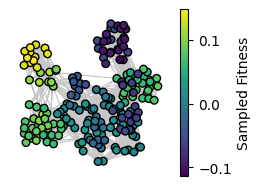

/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_25791/804501729.py:32: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(sm, label='Variance')


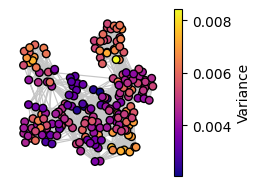

In [65]:
#Fit variance
sigma_squared = np.var(signal0, ddof=1)
#Timestep = 10
t0 = 10

#Generate sample under heat diffusion model and Gaussian Markov random field.
h0_sample = gaussian_markov_random_field.generate_sample_H0(G=G,
                                                            sigma_squared=sigma_squared,
                                                            t=t0)

fig, ax = plt.subplots(figsize=(2.5, 1.75), constrained_layout=True)

norm0, cmap0 = graph_utils.visualize_signal_over_graph(G=G, pos=pos, signal=h0_sample, ax=ax, nodesize=30)
sm = plt.cm.ScalarMappable(cmap=cmap0, norm=norm0)
sm.set_array([]) 
fig.colorbar(sm, label='Sampled Fitness')

plt.savefig('../figures/figure_2/panel_c.pdf', bbox_inches='tight')
plt.show()


variances_H0, Sigma_H0 = gaussian_markov_random_field.compute_variances_H0(sigma_squared=sigma_squared,
                                                                           t=t_map,
                                                                           G=G)


fig, ax = plt.subplots(figsize=(2.5, 1.75), constrained_layout=True)

norm0, cmap0 = graph_utils.visualize_signal_over_graph(G=G, pos=pos, signal=variances_H0, ax=ax, nodesize=30, cmap='plasma')
sm = plt.cm.ScalarMappable(cmap=cmap0, norm=norm0)
sm.set_array([]) 
fig.colorbar(sm, label='Variance')

plt.savefig('../figures/figure_2/panel_d.pdf', bbox_inches='tight')
plt.show()

The cell below plots the covariance matrix of the GMRF parameterised with `t_map` for an elementary landscape. 

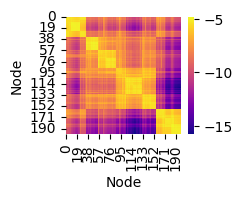

In [66]:
fig = plt.subplots(figsize=(2.6, 2.1))
sns.heatmap(np.log(Sigma_H0), cmap='plasma')
plt.xlabel('Node')
plt.ylabel('Node')
plt.tight_layout()
plt.savefig('../figures/figure_2/panel_e_covariance_matrix.pdf')
plt.show()


The below cell computes the posterior distributions for the t parameter using `fit_t_bayesian_laplace`, for `G0` and `G1`.

## Laplacian Eigenvector landscapes
Landscapes are initialised from a realistic simulation of evolution over a phylogenetic tree. The fitness / signal at each node is assigned according to the `n`th Laplacian eigenvector. As `n` increases, the complexity / frequency of the eigenmode increases and the landscape becomes more rugged. 

The below cell simulates different fitness landscapes with `sequence_evolution.sequence_evolution` and `graph_ruggedness_de.compute_elementary_landscape`, and computes their likelihoods with `timeste_opt.fit_t_bayesian_laplace` at different levels of controlled ruggedness. 

In [3]:
rep_dict = {}
rep_de_dict = {}
rep_sample_info_dict = {}

#Iterate through landscape simulations.

for replicate in range(100):
    #Sample evolutionary parameters.
    num_nodes = np.random.randint(100, 1000)
    mean_branch_length = np.random.uniform(0.01, 0.5)
    std_dev_branch_length = np.random.uniform(0.001, 0.1)
    alpha = np.random.uniform(0.1, 0.5)
    model = random.choice(('WAG', 'LG'))
    rate_categoies = 4
    sequence_length = int(np.random.uniform(100, 1000))

    sample_info = {
        'num_nodes' : num_nodes,
        'std_dev_branch_length' : std_dev_branch_length,
        'mean_branch_length' : mean_branch_length,
        'alpha' : alpha,
        'model' : model,
        'sequence_length' : sequence_length
    }

    #Perform sequence evolution.
    seq_dict = sequence_evolution.sequence_evolution(num_nodes=num_nodes,
                                                    mean_branch_length=mean_branch_length,
                                                    std_dev_branch_length=std_dev_branch_length,
                                                    alpha=alpha,
                                                    model=model,
                                                    rate_categories=rate_categoies,
                                                    sequence_length=sequence_length
                                                    )
    #Construct graph from simulated sequences.

    seq_ls = list(seq_dict.values())
    values = [0]*len(seq_ls)
    G = graph_ruggedness_de.build_ohe_graph(seq_ls=seq_ls,
                                        values=values)
    tmap_dict = {}

    eign_list = list(range(1, int(0.26 * G.number_of_nodes())))
    
    #Iterate through Laplacian eigenvectors.
    for eign in eign_list:
        
        #Assign fitness scores as eigenvectors.
        G_elem = graph_ruggedness_de.compute_elementary_landscape(G=G, n=eign)

        #Compute t parameter.
        t_map, ci_lower, ci_upper, logpost_map, _ = fit_t_bayesian_laplace(G=G_elem, t_max=100, t_min=0.001)
        tmap_dict[eign] = t_map

    
    #Store evolutionary parameters.
    rep_sample_info_dict[replicate] = sample_info

    rep_dict[replicate] = tmap_dict

Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 9408 KNN edges.
Connecting components
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 28770 KNN edges.
Connecting components
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 1848 KNN edges.
Connecting components
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 9828 KNN edges.
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 2912 KNN edges.
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 25926 KNN edges.
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 25636 KNN edges.
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done.
Added 11506 KNN edges.
Computing all vs. all OHE distance matrix.
Done.
Finding K-nearest neighbors.
Done

In [4]:
rep_sample_info_dict

{0: {'num_nodes': 448,
  'std_dev_branch_length': 0.03293200863507989,
  'mean_branch_length': 0.09302538090999317,
  'alpha': 0.34895835950286325,
  'model': 'WAG',
  'sequence_length': 968},
 1: {'num_nodes': 959,
  'std_dev_branch_length': 0.007804955157003093,
  'mean_branch_length': 0.07700580116931625,
  'alpha': 0.3104020088415445,
  'model': 'LG',
  'sequence_length': 745},
 2: {'num_nodes': 154,
  'std_dev_branch_length': 0.07242939574139982,
  'mean_branch_length': 0.47534463456146464,
  'alpha': 0.3555167771146063,
  'model': 'WAG',
  'sequence_length': 989},
 3: {'num_nodes': 468,
  'std_dev_branch_length': 0.044909726305261626,
  'mean_branch_length': 0.0662721455385851,
  'alpha': 0.1872068578316003,
  'model': 'LG',
  'sequence_length': 450},
 4: {'num_nodes': 208,
  'std_dev_branch_length': 0.09770166580659329,
  'mean_branch_length': 0.10139084915767196,
  'alpha': 0.25649625730358094,
  'model': 'WAG',
  'sequence_length': 571},
 5: {'num_nodes': 894,
  'std_dev_branc

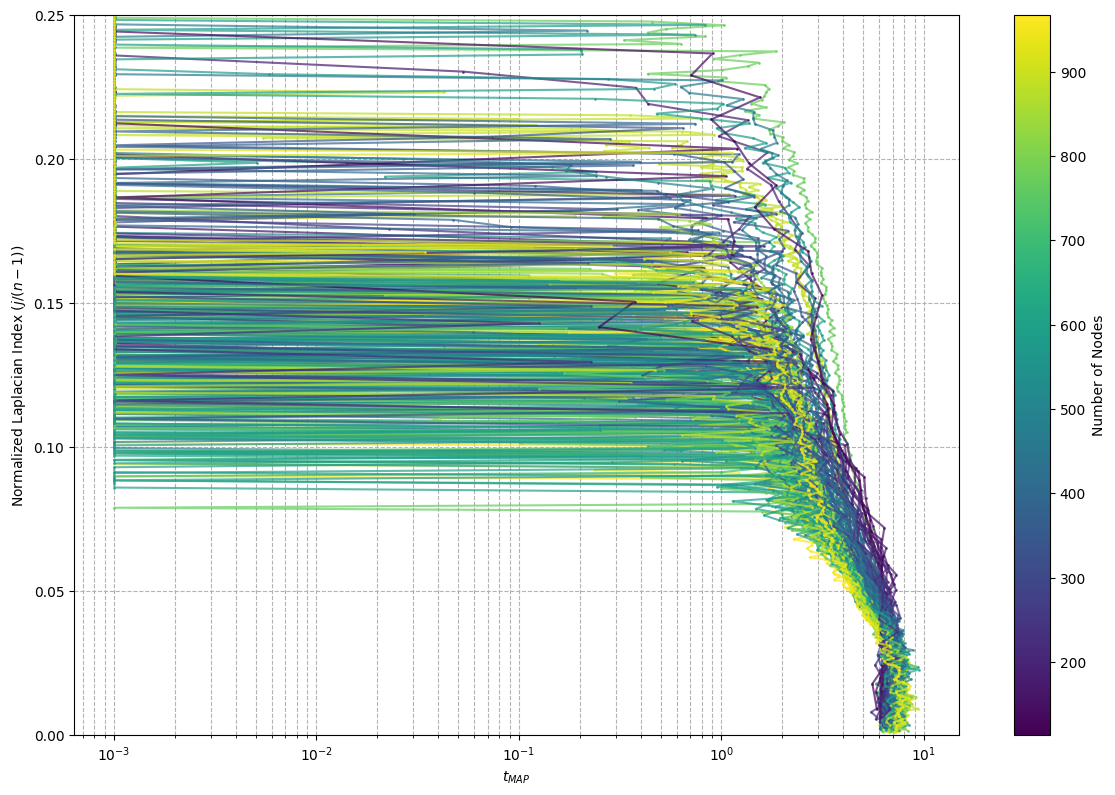

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

all_num_nodes = [info['num_nodes'] for info in rep_sample_info_dict.values()]
if not all_num_nodes:
    raise ValueError("rep_sample_info_dict is empty or does not contain 'num_nodes'")
    
min_nodes = min(all_num_nodes)
max_nodes = max(all_num_nodes)

norm = mcolors.Normalize(vmin=min_nodes, vmax=max_nodes)
cmap = plt.get_cmap('viridis')
scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)

for replicate_id, tmap_dict in rep_dict.items():
    if not tmap_dict:
        continue
    try:
        num_nodes = rep_sample_info_dict[replicate_id]['num_nodes']
    except KeyError:
        print(f"Warning: Could not find info for replicate {replicate_id}. Skipping.")
        continue

    indices = np.array(list(tmap_dict.keys()))
    tmaps = np.array(list(tmap_dict.values()))
    
    normalized_indices = indices / (num_nodes - 1)
    
    line_color = cmap(norm(num_nodes))
    
    ax.plot(tmaps, normalized_indices, color=line_color, alpha=0.7, marker='.', markersize=2, linestyle='-')
    
ax.set_xlabel('$t_{MAP}$')
ax.set_ylabel('Normalized Laplacian Index ($j / (n-1)$)')
ax.set_xscale('log')
ax.grid(True, which="both", ls="--", c='0.7')

cbar = fig.colorbar(scalar_mappable, ax=ax)
cbar.set_label('Number of Nodes')

plt.tight_layout()
plt.ylim(0, 0.25)
plt.show()

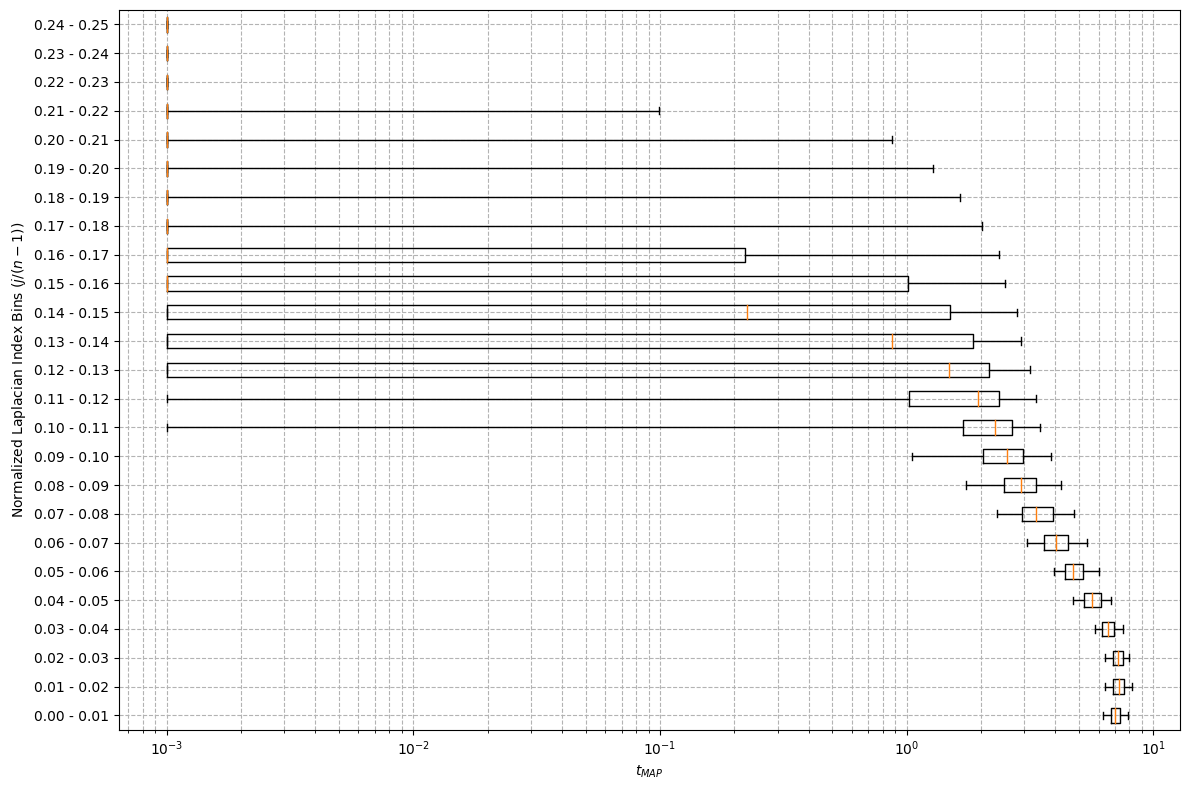

In [10]:
binned_tmaps = defaultdict(list)
bin_width = 0.01
bins = np.arange(0, 0.25 + bin_width, bin_width)
for replicate_id, tmap_dict in rep_dict.items():
    num_nodes = rep_sample_info_dict[replicate_id]['num_nodes']
    if num_nodes <= 1:
        continue # Avoid division by zero
    for index, t_map in tmap_dict.items():
        normalized_index = index / (num_nodes - 1)
        
        bin_index = np.digitize(normalized_index, bins) - 1
        if 0 <= bin_index < len(bins) - 1:
            binned_tmaps[bin_index].append(t_map)

sorted_bin_indices = sorted(binned_tmaps.keys())
data_to_plot = [binned_tmaps[i] for i in sorted_bin_indices]

tick_labels = [f'{bins[i]:.2f} - {bins[i+1]:.2f}' for i in sorted_bin_indices]
fig, ax = plt.subplots(figsize=(12, 8))

ax.boxplot(data_to_plot, vert=False, labels=tick_labels, whis=[5, 95], showfliers=False)

ax.set_xlabel('$t_{MAP}$')
ax.set_xscale('log')
ax.set_ylabel('Normalized Laplacian Index Bins ($j / (n-1)$)')
ax.grid(True, which="both", ls="--", c='0.7')

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

all_bl = [info[''] for info in rep_sample_info_dict.values()]
all_num_nodes = [info['num_nodes'] for info in rep_sample_info_dict.values()]
    
min_nodes = min(all_num_nodes)
max_nodes = max(all_num_nodes)

norm = mcolors.Normalize(vmin=min_nodes, vmax=max_nodes)
cmap = plt.get_cmap('viridis')
scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)

for replicate_id, tmap_dict in rep_dict.items():
    if not tmap_dict:
        continue
    try:
        num_nodes = rep_sample_info_dict[replicate_id]['num_nodes']
    except KeyError:
        print(f"Warning: Could not find info for replicate {replicate_id}. Skipping.")
        continue

    indices = np.array(list(tmap_dict.keys()))
    tmaps = np.array(list(tmap_dict.values()))
    
    normalized_indices = indices / (num_nodes - 1)
    
    line_color = cmap(norm(num_nodes))
    
    ax.plot(tmaps, normalized_indices, color=line_color, alpha=0.7, marker='.', markersize=2, linestyle='-')
    
ax.set_xlabel('$t_{MAP}$')
ax.set_ylabel('Normalized Laplacian Index ($j / (n-1)$)')
ax.set_xscale('log')
ax.grid(True, which="both", ls="--", c='0.7')

cbar = fig.colorbar(scalar_mappable, ax=ax)
cbar.set_label('Number of Nodes')

plt.tight_layout()
plt.show()

The below cells perform statistical tests (ANOVA and post-hoc tukey HSD) to determine staitsitcal significance of relationship between log-likelihood and the Laplacian eigenvector index (i.e. the controlled ruggedness element).

In [ ]:
# Group log-likelihood values by the Laplacian eigenvector index.
groups = [df[df['laplacian_idx'] == k]['BF'].values for k in k_parameters]

# Perform ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_value}")

comp = mc.MultiComparison(df['BF'], df['laplacian_idx'])
post_hoc_res = comp.tukeyhsd()

KeyError: 'laplacian_idx'

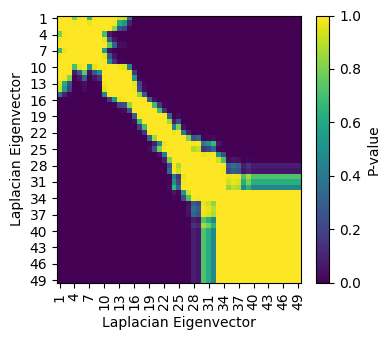

In [22]:
groups = list(post_hoc_res.groupsunique)
p_values = post_hoc_res.pvalues
post_hoc_res_df = pd.DataFrame(post_hoc_res.summary()).drop(0, axis=0)
matrix_size = len(groups)
p_matrix = np.ones((matrix_size, matrix_size))

group1 = [int(str(cell)) for cell in post_hoc_res_df[0]]
group2 = [int(str(cell)) for cell in post_hoc_res_df[1]]

for g1, g2, p in zip(group1, group2, p_values):
    idx1 = g1 - 1 
    idx2 = g2 - 1 
    p_matrix[idx1, idx2] = p
    p_matrix[idx2, idx1] = p  

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(p_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, label='P-value', ax=ax)
tick_indices = list(range(0, matrix_size, 3))
tick_labels = [groups[i] for i in tick_indices]

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=90)
plt.yticks(ticks=tick_indices, labels=tick_labels)
plt.xlabel('Laplacian Eigenvector')
plt.ylabel('Laplacian Eigenvector')
plt.tight_layout()
plt.savefig('../si_figures/si_figure_1/panel_a.pdf')
plt.show()

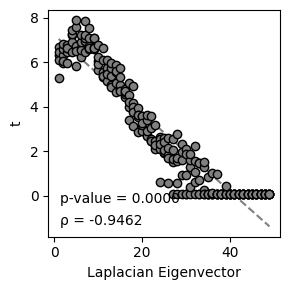

In [23]:
rho, p_value = spearmanr(df['laplacian_idx'], df['BF'])
slope, intercept = np.polyfit(df['laplacian_idx'], df['BF'], 1)
best_fit_line = np.array(df['laplacian_idx']) * slope + intercept

fig = plt.subplots(figsize=(3, 3))

plt.xlabel('Laplacian Eigenvector')
plt.ylabel('t')
plt.plot(df['laplacian_idx'], best_fit_line, color='grey', linestyle='--', zorder=1)

plt.scatter(df['laplacian_idx'], df['BF'], color='grey', linewidths=1, edgecolors='black')
plt.text(0.05, 0.05, f'ρ = {rho:.4f}', transform=plt.gca().transAxes, fontsize=10)
plt.text(0.05, 0.15, f'p-value = {p_value:.4f}', transform=plt.gca().transAxes, fontsize=10)
plt.tight_layout()
plt.savefig('../si_figures/si_figure_1/panel_b.pdf')
plt.show()

## NK-landscape simulations
NK landscapes are initialised with two parameters: `n`, the number of sites in the sequence and `k`, the number of sites that interact. Therefore, fitness landscapes where `k` is high (approaching `n`) resemble rugged / epistatic landscapes. 

The below cell simulates NK landscapes using `nk_landscape.generate_nk_landscape_amino_acids` at different values of `n` and `k`. The `t_map` of each landscape is measured analogous to the Laplacian eigenvector simulated landscapes above. 

In [67]:
# Initialise NK results
nk_rep_dict = {}
n_list = list(range(4,9))
#Iterate through NK simulations.

for replicate in range(50):
    
    tmap_dict = {}
    
    #Iterate through n and k parameters per simulation.
    for n_param in n_list:
        for k_param in list(range(n_param)):

            #Construct nk landscape
            Gnk = nk_landscape.generate_nk_landscape_amino_acids(N=n_param, K=k_param, amino_acids=['A', 'D'])
            
            # Algebraic connectivity.
            laplacian = nx.laplacian_matrix(Gnk)

            sample_info = {
                'n' : n_param,
                'k' : k_param,
                'num_edges' : Gnk.number_of_edges(),
                'num_nodes' : Gnk.number_of_nodes(),
            }

            t_map, ci_lower, ci_upper, logpost_map, _ = fit_t_bayesian_laplace(G=Gnk, t_max=100, t_min=1e-10)

            tmap_dict[(n_param, k_param)] = {
                'tmap': t_map,
                'sample_dict': sample_info
                }
    
    #Collect results
    nk_rep_dict[replicate] = tmap_dict

The cell below plots the `t_map` dependence on `N` and `K` parameters as a heatmap. This demonstrates that `t_map` is a relative measure.

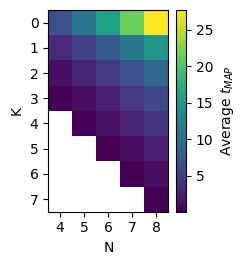

In [68]:
tmap_values = defaultdict(list)
all_n = set()
all_k = set()

for replicate_data in nk_rep_dict.values():
    for (n, k), data in replicate_data.items():
        tmap_values[(n, k)].append(data['tmap'])
        all_n.add(n)
        all_k.add(k)

avg_tmaps = {nk: np.mean(tmaps) for nk, tmaps in tmap_values.items()}

df = pd.DataFrame([
    {'N': n, 'K': k, 't_map': avg_tmaps.get((n, k), np.nan)}
    for n in sorted(list(all_n))
    for k in sorted(list(all_k))
])

heatmap_data = df.pivot(index='K', columns='N', values='t_map')

fig, ax = plt.subplots(figsize=(2.5, 2.75))

n_coords = np.array(heatmap_data.columns, dtype=float) 
k_coords = np.array(heatmap_data.index, dtype=float)
n_coords = np.append(n_coords, n_coords[-1] + 1)
k_coords = np.append(k_coords, k_coords[-1] + 1)

n_coords -= 0.5
k_coords -= 0.5

c = ax.pcolormesh(n_coords, k_coords, heatmap_data, cmap='viridis', shading='auto')

cbar = fig.colorbar(c, ax=ax)
cbar.set_label('Average $t_{MAP}$',)

ax.set_xlabel('N')
ax.set_ylabel('K')

ax.set_xticks(sorted(list(all_n)))
ax.set_yticks(sorted(list(all_k)))

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/figure_2/panel_g_NvsK.pdf')
plt.show()

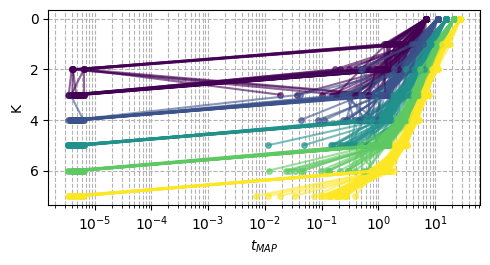

In [ ]:
restructured_data = defaultdict(lambda: defaultdict(list))
all_n_values = set()

for rep, data_dict in nk_rep_dict.items():
    for (n, k), data in data_dict.items():
        restructured_data[rep][n].append((k, data['tmap']))
        all_n_values.add(n)

sorted_n = sorted(list(all_n_values))
fig, ax = plt.subplots(figsize=(5, 2.75))
cmap = plt.get_cmap('viridis')
colors = {n: cmap(i / (len(sorted_n) - 1)) for i, n in enumerate(sorted_n)}

for rep_data in restructured_data.values():
    for n_value, points in rep_data.items():
        points.sort()
        k_vals = [p[0] for p in points]
        tmap_vals = [p[1] for p in points]
        
        ax.plot(tmap_vals, k_vals, color=colors[n_value], alpha=0.6, marker='o', markersize=4, linestyle='-')

ax.set_xlabel('$t_{MAP}$')
ax.set_ylabel('K')

ax.set_xscale('log')
ax.invert_yaxis()

ax.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.savefig('../figures/figure_2/panel_g_Kvstmap.pdf')
plt.show()

The below cells perform ANOVA and post-hoc T-HSD test to find significant differences between the log likelihood and `k` parameters. 

In [26]:

# Group BF values by K_parameter
groups = [df[df['K_parameter'] == k]['BF'].values for k in k_parameters]

# Perform ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_value}")

comp = mc.MultiComparison(df['BF'], df['K_parameter'])
post_hoc_res = comp.tukeyhsd()

ANOVA F-statistic: 2517.4815849835873, p-value: 5.157975975238867e-73


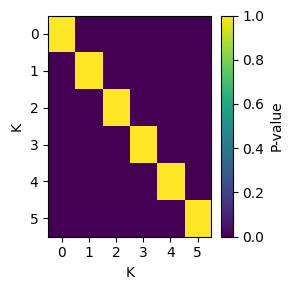

In [27]:
groups = [0, 1, 2, 3, 4, 5]
p_values = post_hoc_res.pvalues

matrix_size = len(groups)
p_matrix = np.ones((matrix_size, matrix_size))

group1 = [0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 4]
group2 = [1, 2, 3, 4, 5, 2, 3, 4, 5, 3, 4, 5, 4, 5, 5]

for g1, g2, p in zip(group1, group2, p_values):
    p_matrix[g1, g2] = p
    p_matrix[g2, g1] = p  # Ensure symmetry

    
fig = plt.subplots(figsize=(3, 3))

plt.imshow(p_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)
plt.colorbar(label='P-value')
plt.xticks(ticks=range(matrix_size), labels=groups)
plt.yticks(ticks=range(matrix_size), labels=groups)

plt.xlabel('K')
plt.ylabel('K')
plt.tight_layout()
plt.savefig('../si_figures/si_figure_2/panel_a.pdf')
plt.show()

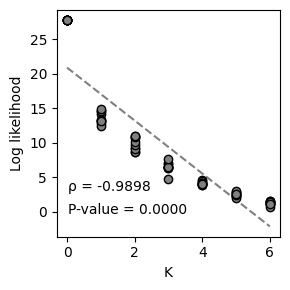

In [28]:
rho, p_value = spearmanr(df['K_parameter'], df['BF'])
slope, intercept = np.polyfit(df['K_parameter'], df['BF'], 1)
best_fit_line = np.array(df['K_parameter']) * slope + intercept

fig = plt.subplots(figsize=(3, 3))

plt.xlabel('K')
plt.ylabel('Log likelihood')
plt.plot(df['K_parameter'], best_fit_line, color='grey', linestyle='--', zorder=1)

# Scatter plot with color based on eigenvalue index
plt.scatter(df['K_parameter'], df['BF'], color='grey', linewidths=1, edgecolors='black')
plt.text(0.05, 0.2, f'ρ = {rho:.4f}', transform=plt.gca().transAxes, fontsize=10)
plt.text(0.05, 0.1, f'P-value = {p:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('../si_figures/si_figure_2/panel_b.pdf')
plt.show()

The below cells test for association between the normalized Laplacian eigenvector index and the N parameter of the NK landscape. 

In [119]:
n_list = list(range(4,9))
#Iterate through NK simulations.
    
tmap_dict = {}

#Iterate through n and k parameters per simulation.
for n_param in n_list:
    
    #Construct nk landscape
    Gnk = nk_landscape.generate_nk_landscape_amino_acids(N=n_param, K=0, amino_acids=['A', 'D'])

    for eig in list(range(1, Gnk.number_of_nodes())):
        
        G_elem = graph_ruggedness_de.compute_elementary_landscape(G=Gnk, n=eig)

        sample_info = {
            'n' : n_param,
            'eig': eig,
            'norm_eig': eig / (Gnk.number_of_nodes() - 1),
            'num_edges' : Gnk.number_of_edges(),
            'num_nodes' : Gnk.number_of_nodes(),
        }

        t_map, ci_lower, ci_upper, logpost_map, _ = fit_t_bayesian_laplace(G=G_elem, t_max=100, t_min=1e-10)

        tmap_dict[(n_param, eig)] = {
            'tmap': t_map,
            'sample_dict': sample_info
            }

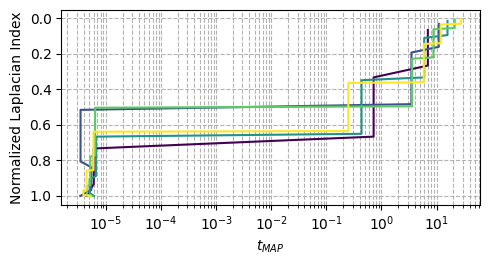

In [127]:
grouped_data = defaultdict(list)
all_n_values = set()
for (n_param, eig), data in tmap_dict.items():
    norm_eig = data['sample_dict']['norm_eig']
    tmap = data['tmap']
    grouped_data[n_param].append((norm_eig, tmap))
    all_n_values.add(n_param)

sorted_n = sorted(list(all_n_values))
fig, ax = plt.subplots(figsize=(5, 2.75))
cmap = plt.get_cmap('viridis')
colors = {n: cmap(i / (len(sorted_n) - 1)) for i, n in enumerate(sorted_n)}
for n_param, points in grouped_data.items():
    
    points.sort()
    norm_indices = [p[0] for p in points]
    tmaps = [p[1] for p in points]
    ax.plot(tmaps, norm_indices, color=colors[n_param], alpha=1, markersize=0, linestyle='-')

ax.set_xlabel('$t_{MAP}$')
ax.set_ylabel('Normalized Laplacian Index')
ax.set_xscale('log')
ax.invert_yaxis()
ax.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.savefig('../figures/figure_2/panel_g_norm_lap_indvstmap.pdf')
plt.show()

The below code demonstrates the distribution of spectral energy in the Laplacian eigenvalues of NK and elementary landscapes.

In [147]:
n_list = list(range(2,9))[::2]
#Iterate through NK simulations.
    
gft_dict = {}

#Iterate through n and k parameters per simulation.
for n_param in n_list:
    
    #Construct nk landscape
    Gnk = nk_landscape.generate_nk_landscape_amino_acids(N=n_param, K=0, amino_acids=['A', 'D'])
    gft_dict[n_param] = graph_fourier_transform.graph_fourier_transform(G=Gnk)

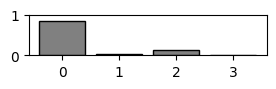

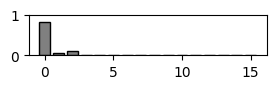

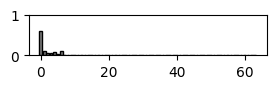

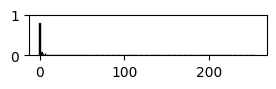

In [152]:
for eig, coeffs in gft_dict.items():
    plt.figure(figsize=(3, 1))
    plt.bar(x=list(range(coeffs.shape[0])), height=coeffs, color='grey', edgecolor='black')
    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(f'../figures/figure_2/panel_g_{eig}_nk_gft.pdf')
    plt.show()

In [135]:
coeffs.shape[0]

256